![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# Text Mining: Models and Algorithms
## Scraping RTA Texts from UNCTAD ToTA via the GitHub JSON API

**Project:** Contract Completeness Index for International Trade Agreements  
**Author:** Rhea D'Costa — Barcelona School of Economics

**Data source:** UNCTAD Texts of Trade Agreements (ToTA)  
https://github.com/mappingtreaties/tota

### Why this source?
The ToTA corpus contains **450 PTA texts notified to the WTO**, each in a clean XML file with consistent structure:
- `<meta>` → agreement name, parties (ISO codes), signing date, WTO notification URL  
- `<body>` → `<chapter>` → `<article>` hierarchy, preserving the legal structure

This is ideal for our CCI because we can compute scores **at the article level** and aggregate up — capturing that a dispute-settlement chapter is qualitatively different from a preamble.

### How we access the data
The GitHub API returns JSON with base64-encoded file content for each XML file.  
The pipeline is therefore: `requests` → JSON → base64 decode → XML parse — no web scraping of rendered HTML needed.  
This is the same `requests.get` → parse pattern from the UN resolutions class, just with XML instead of BeautifulSoup.

**Pre-processing decision logged here:** We preserve the `<chapter>` and `<article>` structure from the XML as the unit of analysis, rather than collapsing to a single string. This lets us compute chapter-level scores (e.g. the dispute-settlement chapter score separately from the market-access chapter score) — a key feature of the CCI.

---
## 0. Imports and Setup

In [4]:

import requests
import base64
import xml.etree.ElementTree as ET
import pandas as pd
import os
import re
import time
from collections import Counter

# NLP — same packages as Session 3
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['figure.dpi'] = 130

# ── GitHub token — loaded from .env (never hard-code tokens in notebooks) ─────
# Each team member:
#   1. Copy .env.example → .env  (this file is in .gitignore, never committed)
#   2. Paste your own ghp_... token into .env
#   3. Run this cell — token is loaded automatically
#
# Without token: 60 req/hr  → enough for ~58 PTAs
# With token:  5,000 req/hr → full 450 corpus in ~15 minutes

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())                                    # reads .env in the current directory
GITHUB_TOKEN = os.getenv('GITHUB_TOKEN', '')       # empty string if not set

GITHUB_API = "https://api.github.com/repos/mappingtreaties/tota/contents/xml"

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/109.0.0.0 Safari/537.36',
}
if GITHUB_TOKEN:
    HEADERS['Authorization'] = f'token {GITHUB_TOKEN}'
    print("✓ GitHub token loaded from .env — authenticated (5,000 req/hr)")
else:
    print("⚠ No token found in .env — unauthenticated (60 req/hr)")
    print("  Copy .env.example → .env and add your token.")

# Check rate limit immediately so we know what we're working with
_rl   = requests.get("https://api.github.com/rate_limit", headers=HEADERS).json()
_core = _rl.get('resources', {}).get('core', _rl.get('rate', {}))
print(f"  Rate limit: {_core.get('remaining','?')} / {_core.get('limit','?')} remaining")

OUTPUT_DIR = "rta_texts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nSetup complete.  Output directory: {OUTPUT_DIR}")


✓ GitHub token loaded from .env — authenticated (5,000 req/hr)
  Rate limit: 5000 / 5000 remaining

Setup complete.  Output directory: rta_texts


---
## Part 1: Inspect the Repository Structure

### 1.1 Get the file listing from the GitHub API

The first step mirrors the class approach exactly: call the URL, get back a list of items, inspect the structure before processing everything.  
Here the GitHub API returns a JSON array — each element describes one file in the `xml/` folder.

In [5]:
# Step 1: fetch the directory listing from the GitHub API

response = requests.get(GITHUB_API, headers=HEADERS)
print("Response status:", response.status_code)
print("Rate limit remaining:", response.headers.get('X-RateLimit-Remaining', 'N/A'))
print("Rate limit total:    ", response.headers.get('X-RateLimit-Limit', 'N/A'))

# Show raw response if not 200 — reveals the exact GitHub error message
if response.status_code != 200:
    print(f"\nERROR response body: {response.text[:500]}")


Response status: 200
Rate limit remaining: 4999
Rate limit total:     5000


In [6]:
# Step 2: parse JSON — get list of all XML files

data = response.json()

# If GitHub returned an error, it's a dict not a list
if isinstance(data, dict):
    print("GitHub API returned an error (not a file list):")
    print(f"  message: {data.get('message', 'no message')}")
    print(f"  docs:    {data.get('documentation_url', '')}")
    print()
    if 'rate limit' in str(data.get('message','')).lower():
        print("FIX: rate limit exhausted.")
        print("  -> Make sure .env has a valid GITHUB_TOKEN and restart the kernel.")
    elif 'bad credential' in str(data.get('message','')).lower():
        print("FIX: token is invalid or expired.")
        print("  -> Generate a new token at github.com/settings/tokens")
        print("     Update .env, restart kernel, re-run from Section 0.")
    raise SystemExit("Fix the error above then restart kernel and re-run from Section 0.")

file_list = data

print(f"Total files in xml/ folder: {len(file_list)}")
print("\nFirst file entry (inspect its keys):")
print(file_list[0])


Total files in xml/ folder: 450

First file entry (inspect its keys):
{'name': 'pta_1.xml', 'path': 'xml/pta_1.xml', 'sha': '278f7d7104b6f6250ac578c18b471536819fcf38', 'size': 209550, 'url': 'https://api.github.com/repos/mappingtreaties/tota/contents/xml/pta_1.xml?ref=master', 'html_url': 'https://github.com/mappingtreaties/tota/blob/master/xml/pta_1.xml', 'git_url': 'https://api.github.com/repos/mappingtreaties/tota/git/blobs/278f7d7104b6f6250ac578c18b471536819fcf38', 'download_url': 'https://raw.githubusercontent.com/mappingtreaties/tota/master/xml/pta_1.xml', 'type': 'file', '_links': {'self': 'https://api.github.com/repos/mappingtreaties/tota/contents/xml/pta_1.xml?ref=master', 'git': 'https://api.github.com/repos/mappingtreaties/tota/git/blobs/278f7d7104b6f6250ac578c18b471536819fcf38', 'html': 'https://github.com/mappingtreaties/tota/blob/master/xml/pta_1.xml'}}


In [7]:
# Step 3: extract the useful fields from each file entry
# 'name'  → filename, e.g. 'pta_1.xml'
# 'url'   → API URL for fetching THIS file's content (returns base64 JSON)
# 'size'  → file size in bytes

# Filter to only .xml files (should be all of them, but good practice)
xml_files = [f for f in file_list if f['name'].endswith('.xml')]

print(f"XML files found: {len(xml_files)}")
print("\nSample entries:")
for f in xml_files[:5]:
    print(f"  {f['name']:20}  size: {f['size']:6} bytes  url: {f['url'][:60]}...")

# Sort numerically by PTA number (pta_1, pta_2, ..., pta_450)
xml_files_sorted = sorted(
    xml_files,
    key=lambda f: int(re.search(r'pta_(\d+)', f['name']).group(1))
)
print(f"\nFirst: {xml_files_sorted[0]['name']}")
print(f"Last:  {xml_files_sorted[-1]['name']}")

XML files found: 450

Sample entries:
  pta_1.xml             size: 209550 bytes  url: https://api.github.com/repos/mappingtreaties/tota/contents/x...
  pta_10.xml            size: 262937 bytes  url: https://api.github.com/repos/mappingtreaties/tota/contents/x...
  pta_100.xml           size:  22839 bytes  url: https://api.github.com/repos/mappingtreaties/tota/contents/x...
  pta_101.xml           size: 274394 bytes  url: https://api.github.com/repos/mappingtreaties/tota/contents/x...
  pta_102.xml           size:  62267 bytes  url: https://api.github.com/repos/mappingtreaties/tota/contents/x...

First: pta_1.xml
Last:  pta_450.xml


---
## Part 2: Fetch and Parse One XML File

### 2.1 Understand the XML structure

Before building the loop, we inspect one file in detail — same class principle as examining `soup.prettify()` before iterating.  

The GitHub API response for a single file contains:
- `content`: the XML file encoded in **base64**
- `encoding`: `"base64"` (always)

We decode it with Python's `base64` module, then parse with `xml.etree.ElementTree`.

Known XML structure (from the ToTA documentation):
```xml
<treaty>
  <meta>
    <name>Agreement name</name>
    <parties>   <party iso="XX"/> ... </parties>
    <year>YYYY</year>
    <source>URL to WTO notification</source>
  </meta>
  <body>
    <chapter name="Preamble">
      <article number="1" name="Objectives">
        <paragraph>Text of paragraph...</paragraph>
        ...
      </article>
    </chapter>
    <chapter name="Trade in Goods">
      ...
    </chapter>
  </body>
</treaty>
```

In [8]:
# Fetch a single file from the API and decode
# Using pta_1.xml as our inspection example (same as class: inspect one before looping)

test_file = xml_files_sorted[0]   # pta_1.xml
print(f"Fetching: {test_file['name']}")
print(f"API URL:  {test_file['url']}")

r = requests.get(test_file['url'], headers=HEADERS)
print(f"Status: {r.status_code}")

file_json = r.json()
print(f"\nKeys in the file response: {list(file_json.keys())}")
print(f"Encoding: {file_json.get('encoding')}")
print(f"Content (first 100 chars of base64): {file_json['content'][:100]}")

Fetching: pta_1.xml
API URL:  https://api.github.com/repos/mappingtreaties/tota/contents/xml/pta_1.xml?ref=master
Status: 200

Keys in the file response: ['name', 'path', 'sha', 'size', 'url', 'html_url', 'git_url', 'download_url', 'type', 'content', 'encoding', '_links']
Encoding: base64
Content (first 100 chars of base64): PD94bWwgdmVyc2lvbj0iMS4wIiBlbmNvZGluZz0iVVRGLTgiPz4KPHRyZWF0
eT4KICA8bWV0YT4KICAgIDxuYW1lPkphcGFuIC0


In [9]:
# Decode base64 → UTF-8 string → parse XML

xml_bytes = base64.b64decode(file_json['content'])
xml_text  = xml_bytes.decode('utf-8')

print("First 800 characters of the raw XML:")
print(xml_text[:800])

First 800 characters of the raw XML:
<?xml version="1.0" encoding="UTF-8"?>
<treaty>
  <meta>
    <name>Japan - Thailand</name>
    <type>Free Trade Agreement &amp; Economic Integration Agreement</type>
    <wto_rta_id>1</wto_rta_id>
    <treaty_identifier>1</treaty_identifier>
    <status>In Force</status>
    <notification>GATT Art. XXIV &amp; GATS Art. V</notification>
    <date_signed>2007-04-03</date_signed>
    <date_into_force>2007-11-01</date_into_force>
    <date_notification>2007-10-25</date_notification>
    <end_implementation>2022-12-31</end_implementation>
    <date_inactive/>
    <parties_original>
      <partyisocode n="1">JPN</partyisocode>
      <partyisocode n="2">THA</partyisocode>
    </parties_original>
    <parties>
      <partyisocode n="1">JPN</partyisocode>
      <partyisocode n="2">THA</partyisocode


In [10]:
# Parse the XML tree and inspect its structure

root = ET.fromstring(xml_text)

print("Root tag:", root.tag)
print("Children of root:", [child.tag for child in root])

# --- META section ---
meta = root.find('meta')
print("\n=== META ===")
for child in meta:
    if child.tag == 'parties':
        parties = [p.text.strip() for p in child.findall('partyisocode') if p.text]
        print(f"  parties: {parties}")
    elif child.tag == 'parties_original':
        pass
    else:
        print(f"  {child.tag}: {child.text}")

# --- BODY section ---
body     = root.find('body')
chapters = body.findall('chapter')
print(f"\n=== BODY: {len(chapters)} chapters ===")
for ch in chapters:
    articles = ch.findall('article')
    print(f"  Chapter: '{ch.get('name')}' — {len(articles)} articles")

# --- Quick article peek using itertext() ---
# Article text is stored DIRECTLY in <article> (no <paragraph> children).
# itertext() captures text whether it's in the element itself or any descendants.
if chapters:
    first_ch  = chapters[0]
    first_art = first_ch.find('article')
    if first_art is not None:
        import re as _re
        art_text = _re.sub(r'\s+', ' ', ' '.join(first_art.itertext())).strip()
        print(f"\nFirst article preview ({len(art_text)} chars, via itertext):")
        print(f"  {art_text[:300]}...")


Root tag: treaty
Children of root: ['meta', 'body']

=== META ===
  name: Japan - Thailand
  type: Free Trade Agreement & Economic Integration Agreement
  wto_rta_id: 1
  treaty_identifier: 1
  status: In Force
  notification: GATT Art. XXIV & GATS Art. V
  date_signed: 2007-04-03
  date_into_force: 2007-11-01
  date_notification: 2007-10-25
  end_implementation: 2022-12-31
  date_inactive: None
  parties: ['JPN', 'THA']
  composition: Bilateral
  region: East Asia
  parties_wto: Yes
  crossregional: No
  language: en
  source: http://www.mofa.go.jp/region/asia-paci/thailand/epa0704/agreement.pdf
  source: http://www.mofa.go.jp/region/asia-paci/thailand/epa0704/index.html

=== BODY: 17 chapters ===
  Chapter: 'Preamble' — 1 articles
  Chapter: 'General Provisions' — 14 articles
  Chapter: 'Trade In Goods' — 12 articles
  Chapter: 'Rules Of Origin' — 23 articles
  Chapter: 'Customs Procedures' — 7 articles
  Chapter: 'Paperless Trading' — 5 articles
  Chapter: 'Mutual Recognition' — 9 a

In [11]:
# Inspect one article in detail

first_chapter = chapters[0]
first_article = first_chapter.find('article')

print("Article attributes:")
print(f"  number: {first_article.get('number')}")
print(f"  name:   {first_article.get('name')}")
print(f"  tag:    {first_article.tag}")

print("\nArticle direct children:")
children = list(first_article)
if children:
    for child in children:
        print(f"  <{child.tag}> text={str(child.text)[:80]}")
else:
    print("  (no child elements — text is stored directly in <article>)")

# Correct extraction: itertext() — works whether text is direct or in sub-elements
import re as _re
art_text = _re.sub(r'\s+', ' ', ' '.join(first_article.itertext())).strip()
print(f"\nFull article text via itertext() ({len(art_text)} chars):")
print(art_text[:400])


Article attributes:
  number: None
  name:   None
  tag:    article

Article direct children:
  (no child elements — text is stored directly in <article>)

Full article text via itertext() (2069 chars):
Preamble Japan and the Kingdom of Thailand (hereinafter referred to in this Agreement as “the Parties”), Conscious of their warm relations and strong economic and political ties, including shared perceptions on various issues, that have developed through many years of fruitful and mutually beneficial cooperation; Recognising that the economic partnership of the Parties would create larger and new 


---
## Part 3: The Parsing Function

Now we write a single function that takes an XML string and returns:
1. A metadata dict (name, parties, year, source)
2. A list of article-level records — one per article, with chapter and article metadata

This mirrors the `download_resolutions_quick(year)` structure from class: one clean function that handles all the parsing, then we loop over it.

In [12]:

def parse_tota_xml(xml_text, pta_id):
    """
    Parses one ToTA XML string. Returns (meta_dict, articles_list).

    Key finding: article text is stored DIRECTLY in <article> tags (or in
    nested <paragraph> sub-tags depending on the file). Using itertext()
    captures both cases reliably.
    """
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError as e:
        print(f"  XML parse error in pta_{pta_id}: {e}")
        return None, []

    meta = root.find('meta')
    if meta is None:
        return None, []

    # ── Scalar meta fields ────────────────────────────────────────────────────
    name          = meta.findtext('name',            default='').strip()
    rta_type      = meta.findtext('type',            default='').strip()
    status        = meta.findtext('status',          default='').strip()
    notification  = meta.findtext('notification',    default='').strip()
    date_signed   = meta.findtext('date_signed',     default='').strip()
    date_force    = meta.findtext('date_into_force', default='').strip()
    composition   = meta.findtext('composition',     default='').strip()
    region        = meta.findtext('region',          default='').strip()
    crossregional = meta.findtext('crossregional',   default='').strip()
    parties_wto   = meta.findtext('parties_wto',     default='').strip()
    language      = meta.findtext('language',        default='').strip()
    wto_rta_raw   = meta.findtext('wto_rta_id',      default='').strip()

    year = date_signed[:4] if date_signed else meta.findtext('year', default='').strip()

    try:
        wto_rta_id = int(wto_rta_raw) if wto_rta_raw else None
    except ValueError:
        wto_rta_id = None

    parties_el = meta.find('parties')
    parties = ([p.text.strip() for p in parties_el.findall('partyisocode')
                if p.text and p.text.strip()]
               if parties_el is not None else [])

    meta_dict = {
        'pta_id':          pta_id,
        'name':            name,
        'parties':         parties,
        'n_parties':       len(parties),
        'year':            year,
        'date_signed':     date_signed,
        'date_into_force': date_force,
        'status':          status,
        'type':            rta_type,
        'notification':    notification,
        'composition':     composition,
        'region':          region,
        'crossregional':   crossregional,
        'parties_wto':     parties_wto,
        'language':        language,
        'wto_rta_id':      wto_rta_id,
    }

    # ── Body ──────────────────────────────────────────────────────────────────
    body = root.find('body')
    if body is None:
        return meta_dict, []

    articles = []
    for ch_idx, chapter in enumerate(body.findall('chapter')):
        chapter_name = chapter.get('name', f'Chapter_{ch_idx}')
        for article in chapter.findall('article'):
            art_number = article.get('number', '')
            art_name   = article.get('name',   '')

            # itertext() collects ALL text from the element and ALL descendants,
            # whether stored directly in <article> or in nested <paragraph> tags.
            art_text   = re.sub(r'\s+', ' ', ' '.join(article.itertext())).strip()
            word_count = len(art_text.split())

            if word_count > 0:
                articles.append({
                    'pta_id':         pta_id,
                    'agreement_name': name,
                    'year':           year,
                    'chapter_name':   chapter_name,
                    'chapter_index':  ch_idx,
                    'article_number': art_number,
                    'article_name':   art_name,
                    'article_text':   art_text,
                    'word_count':     word_count,
                })

    return meta_dict, articles


# ── Self-contained test ───────────────────────────────────────────────────────
import os, base64, xml.etree.ElementTree as ET

_test_xml_path = os.path.join(OUTPUT_DIR, 'pta_1.xml')
if os.path.exists(_test_xml_path):
    with open(_test_xml_path, encoding='utf-8') as _fh:
        _test_xml = _fh.read()
    print(f"Loaded pta_1.xml from disk ({len(_test_xml):,} chars)")
else:
    print("Fetching pta_1.xml from GitHub...")
    _r = requests.get(
        "https://api.github.com/repos/mappingtreaties/tota/contents/xml/pta_1.xml",
        headers=HEADERS)
    _test_xml = base64.b64decode(_r.json()['content']).decode('utf-8')

_meta, _arts = parse_tota_xml(_test_xml, pta_id=1)

print(f"\nArticles extracted: {len(_arts)}")
if _arts:
    print(f"Parties: {_meta['parties']}")
    print(f"WTO RTA ID: {_meta['wto_rta_id']}")
    print("\nFirst 3 articles:")
    for a in _arts[:3]:
        print(f"  [{a['chapter_name']}] Art.{a['article_number']} "
              f"'{a['article_name']}' — {a['word_count']} words")
        print(f"    {a['article_text'][:150]}...")
else:
    print("Still 0 — paste this output for further debugging.")


Fetching pta_1.xml from GitHub...

Articles extracted: 175
Parties: ['JPN', 'THA']
WTO RTA ID: 1

First 3 articles:
  [Preamble] Art. '' — 308 words
    Preamble Japan and the Kingdom of Thailand (hereinafter referred to in this Agreement as “the Parties”), Conscious of their warm relations and strong ...
  [General Provisions] Art.ARTICLE 1 'Objectives' — 143 words
    The objectives of this Agreement are to: (a) liberalise and facilitate trade in goods and services between the Parties; (b) realise and promote paperl...
  [General Provisions] Art.ARTICLE 2 'General Definitions' — 162 words
    For the purposes of this Agreement, unless otherwise specified: (a) the term “GATS” means the General Agreement on Trade in Services in Annex 1B to th...


---
## Part 4: Full Corpus Download Loop

Now we loop over all 450 PTA files. This is the `download_resolutions_quick(year)` loop from class — one function, iterate, store results.

**Rate limit note:**  
Without a GitHub token: 60 requests/hour. For 450 files + the 1 initial listing call = 451 requests total → you need a token, or run in batches with `time.sleep()`.  
**With a token (strongly recommended):** 5,000 requests/hour → full corpus in ~10 minutes.  

Add your token: go to GitHub → Settings → Developer Settings → Personal Access Tokens → Generate New Token (no scopes needed for public repos).

In [13]:

# ── Rate limit reminder (token is set in Section 0) ──────────────────────────
# If you see "remaining: 0" here, your token wasn't set before running Section 0.
# Fix: paste your token in Section 0, then Kernel → Restart & Run All.

_rl = requests.get("https://api.github.com/rate_limit", headers=HEADERS).json()
_core = _rl.get('resources', {}).get('core', _rl.get('rate', {}))
remaining = _core.get('remaining', 0)
limit     = _core.get('limit', 0)

print(f"Rate limit: {remaining} / {limit} remaining")
if 'reset' in _core:
    print(f"Resets at:  {pd.Timestamp(_core['reset'], unit='s')}")

if remaining < limit * 0.1:
    print("\n⚠ Less than 10% of rate limit left.")
    print("  Stop here, wait for reset, or set a token in Section 0.")
elif limit >= 5000:
    total_requests_needed = len(xml_files_sorted) + 1   # +1 for directory listing
    print(f"\n✓ Authenticated. {remaining} requests remaining.")
    print(f"  Requests needed for full corpus: {total_requests_needed}")
    print(f"  You have enough — proceed to the download cell.")
else:
    print(f"\n⚠ Unauthenticated (60/hr). Only safe for ~{remaining - 1} more PTAs.")
    print("  Set GITHUB_TOKEN in Section 0 for full corpus run.")


Rate limit: 4997 / 5000 remaining
Resets at:  2026-03-15 17:05:54

✓ Authenticated. 4997 requests remaining.
  Requests needed for full corpus: 451
  You have enough — proceed to the download cell.


In [14]:

# ── Corpus download function ──────────────────────────────────────────────────

META_COLS = [
    'pta_id', 'name', 'parties', 'n_parties', 'year',
    'date_signed', 'date_into_force', 'status', 'type',
    'notification', 'composition', 'region', 'crossregional',
    'parties_wto', 'language', 'wto_rta_id',
]
ARTICLE_COLS = [
    'pta_id', 'agreement_name', 'year', 'chapter_name', 'chapter_index',
    'article_number', 'article_name', 'article_text', 'word_count',
]

def download_tota_corpus(file_list, max_ptas=None, sleep=0.5, save_xml=True):
    """
    Downloads and parses ToTA XML files from GitHub API.

    Args:
        file_list:   sorted list of file entries from the GitHub API directory listing
        max_ptas:    integer limit for pilot runs (None = all 450)
        sleep:       seconds between API calls
        save_xml:    if True, save raw XML to OUTPUT_DIR/ for offline re-use

    Returns:
        df_meta:     DataFrame, one row per agreement
        df_articles: DataFrame, one row per article
        errors:      list of dicts for any failed files
    """
    all_meta     = []
    all_articles = []
    errors       = []

    targets = file_list[:max_ptas] if max_ptas else file_list
    total   = len(targets)

    print(f"Downloading {total} PTAs from ToTA GitHub repo...")
    print("=" * 60)

    for i, f in enumerate(targets):
        fname  = f['name']
        pta_id = int(re.search(r'pta_(\d+)', fname).group(1))
        url    = f['url']

        r = requests.get(url, headers=HEADERS)

        if (i + 1) % 10 == 0 or i < 5:
            rl_remaining = r.headers.get('X-RateLimit-Remaining', '?')
            print(f"[{i+1:3}/{total}] pta_{pta_id:3}  status={r.status_code}  "
                  f"rate_remaining={rl_remaining}")

        if r.status_code != 200:
            print(f"  ERROR: {r.status_code} on {fname}")
            errors.append({'pta_id': pta_id, 'fname': fname, 'status': r.status_code})
            time.sleep(sleep)
            continue

        try:
            file_json = r.json()
            xml_bytes = base64.b64decode(file_json['content'])
            xml_text  = xml_bytes.decode('utf-8')
        except Exception as e:
            print(f"  Decode error on {fname}: {e}")
            errors.append({'pta_id': pta_id, 'fname': fname, 'status': 'decode_error'})
            time.sleep(sleep)
            continue

        if save_xml:
            with open(os.path.join(OUTPUT_DIR, fname), 'w', encoding='utf-8') as out:
                out.write(xml_text)

        meta_dict, articles = parse_tota_xml(xml_text, pta_id)
        if meta_dict:
            all_meta.append(meta_dict)
        all_articles.extend(articles)

        time.sleep(sleep)

    df_meta     = (pd.DataFrame(all_meta,     columns=META_COLS)
                   if all_meta     else pd.DataFrame(columns=META_COLS))
    df_articles = (pd.DataFrame(all_articles, columns=ARTICLE_COLS)
                   if all_articles else pd.DataFrame(columns=ARTICLE_COLS))

    print("\n" + "=" * 60)
    print(f"Done.")
    print(f"  Agreements parsed:  {len(df_meta)}")
    print(f"  Article records:    {len(df_articles)}")
    print(f"  Errors:             {len(errors)}")
    if errors:
        print(f"  First error:        {errors[0]}")
    if len(df_articles) == 0 and len(df_meta) > 0:
        print("\n  ⚠ Metadata OK but 0 articles — re-run Part 3 test cell to inspect body structure.")

    return df_meta, df_articles, errors


print("Function defined.")


Function defined.


In [15]:

# ── PILOT RUN: first 20 agreements ───────────────────────────────────────────

df_meta_pilot, df_articles_pilot, errors_pilot = download_tota_corpus(
    xml_files_sorted,
    max_ptas=None,     # change to None for full corpus (needs GitHub token)
    sleep=0.8,
    save_xml=True
)

print("\nMetadata sample:")
display(df_meta_pilot[['pta_id', 'name', 'parties', 'year']].head(10))

print("\nArticle data sample:")
if len(df_articles_pilot) > 0:
    display(df_articles_pilot[['pta_id', 'agreement_name', 'chapter_name',
                                'article_number', 'word_count']].head(10))
else:
    print("\n⚠ df_articles is empty — inspecting raw XML structure:")
    sample_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.xml')]
    if sample_files:
        sample_path = os.path.join(OUTPUT_DIR, sorted(sample_files)[0])
        with open(sample_path, encoding='utf-8') as fh:
            raw = fh.read()
        root_dbg = ET.fromstring(raw)
        for child in root_dbg:
            grandchildren = list(child)
            for gc in grandchildren[:3]:
                ggc = list(gc)
                print(f"  <{child.tag}> → <{gc.tag}> attrs={gc.attrib}")
                for ggc_el in ggc[:3]:
                    print(f"    <{ggc_el.tag}> text={repr(ggc_el.text)[:60]}")
    else:
        print("  No XML files in rta_texts/ — check rate limits above.")


[  1/450] pta_  1  status=200  rate_remaining=4996
[  2/450] pta_  2  status=200  rate_remaining=4995
[  3/450] pta_  3  status=200  rate_remaining=4994
[  4/450] pta_  4  status=200  rate_remaining=4993
[  5/450] pta_  5  status=200  rate_remaining=4992
[ 10/450] pta_ 10  status=200  rate_remaining=4987
[ 20/450] pta_ 20  status=200  rate_remaining=4977
[ 30/450] pta_ 30  status=200  rate_remaining=4967
[ 40/450] pta_ 40  status=200  rate_remaining=4957
[ 50/450] pta_ 50  status=200  rate_remaining=4947
[ 60/450] pta_ 60  status=200  rate_remaining=4937
[ 70/450] pta_ 70  status=200  rate_remaining=4927
[ 80/450] pta_ 80  status=200  rate_remaining=4917
[ 90/450] pta_ 90  status=200  rate_remaining=4907
[100/450] pta_100  status=200  rate_remaining=4897
[110/450] pta_110  status=200  rate_remaining=4887
[120/450] pta_120  status=200  rate_remaining=4877
[130/450] pta_130  status=200  rate_remaining=4867
[140/450] pta_140  status=200  rate_remaining=4857
[150/450] pta_150  status=200  

,pta_id,name,parties,year
0,1,Japan - Thailand,"[JPN, THA]",2007
1,2,Egypt - Turkey,"[EGY, TUR]",2005
2,3,Chile - Japan,"[CHL, JPN]",2007
3,4,Central European Free Trade Agreement (CEFTA) ...,"[ALB, BIH, MDA, MKD, MNE, RKS, SRB]",2006
4,5,EFTA - Egypt,"[CHE, EGY, ISL, LIE, NOR]",2007
5,6,Southern African Customs Union (SACU),"[BWA, LSO, NAM, SWZ, ZAF]",2002
6,7,Chile - China,"[CHL, CHN]",2005
7,8,Trans-Pacific Strategic Economic Partnership,"[BRN, CHL, NZL, SGP]",2005
8,9,India - Singapore,"[IND, SGP]",2005
9,10,Panama - Singapore,"[PAN, SGP]",2006



Article data sample:


,pta_id,agreement_name,chapter_name,article_number,word_count
0,1,Japan - Thailand,Preamble,,308
1,1,Japan - Thailand,General Provisions,ARTICLE 1,143
2,1,Japan - Thailand,General Provisions,ARTICLE 2,162
3,1,Japan - Thailand,General Provisions,ARTICLE 3,175
4,1,Japan - Thailand,General Provisions,ARTICLE 4,55
5,1,Japan - Thailand,General Provisions,ARTICLE 5,119
6,1,Japan - Thailand,General Provisions,ARTICLE 6,137
7,1,Japan - Thailand,General Provisions,ARTICLE 7,32
8,1,Japan - Thailand,General Provisions,ARTICLE 8,79
9,1,Japan - Thailand,General Provisions,ARTICLE 9,86


In [16]:

# ── FULL CORPUS RUN ───────────────────────────────────────────────────────────
# Uncomment when ready to download all 450 agreements.
# Requires token in Section 0 (5,000 req/hr).
# Expected runtime: ~15 minutes at sleep=0.5

# df_meta, df_articles, errors = download_tota_corpus(
#     xml_files_sorted,
#     max_ptas=None,   # all 450
#     sleep=0.5,
#     save_xml=True
# )

# Use pilot data for the rest of this notebook until full run is complete
df_meta     = df_meta_pilot.copy()
df_articles = df_articles_pilot.copy()

print(f"Working with: {len(df_meta)} agreements, {len(df_articles)} articles")


Working with: 449 agreements, 40486 articles


---
## Part 5: Descriptive Statistics — "Start Slow, End High"

The professor explicitly asks for a data description with summary statistics and meaningful figures before analysis. Here we characterize the corpus.

In [17]:
# ── Corpus summary ────────────────────────────────────────────────────────────

# Agreement-level summary
df_agree_summary = df_articles.groupby(['pta_id', 'agreement_name', 'year']).agg(
    n_articles   = ('article_text', 'count'),
    n_chapters   = ('chapter_name', 'nunique'),
    total_words  = ('word_count', 'sum'),
    avg_art_len  = ('word_count', 'mean')
).reset_index()

df_agree_summary['year'] = pd.to_numeric(df_agree_summary['year'], errors='coerce')

print("=== PILOT CORPUS SUMMARY ===")
print(f"Agreements: {len(df_agree_summary)}")
print(f"Articles:   {len(df_articles)}")
print(f"Total words: {df_agree_summary['total_words'].sum():,}")
print()
print(df_agree_summary[['agreement_name','year','n_chapters','n_articles','total_words']]
      .sort_values('total_words', ascending=False).to_string(index=False))

=== PILOT CORPUS SUMMARY ===
Agreements: 449
Articles:   40486
Total words: 6,781,313

                                                                             agreement_name  year  n_chapters  n_articles  total_words
                                                                  Trans-Pacific Partnership  2016          31         508       145297
                                                                               EU - Ukraine  2014          51         489        79260
                                                North American Free Trade Agreement (NAFTA)  1992          24         298        78901
       Dominican Republic - Central America - United States Free Trade Agreement (CAFTA-DR)  2004          24         279        76892
                                                                              US - Colombia  2006          25         282        75408
                                                                                  US - Peru  2006      

In [18]:
# ── Chapter coverage: which chapters exist across agreements? ─────────────────
# This tells us the breadth of issue coverage (one component of D2 in the CCI)

chapter_counts = (
    df_articles
    .groupby('chapter_name')['pta_id']
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

print("Most common chapter names across pilot corpus:")
print(chapter_counts)

Most common chapter names across pilot corpus:
chapter_name
Preamble                               323
Conclusion                             288
General Provisions                     149
Chapter_1                              127
Chapter_0                              124
Final Provisions                       114
Industrial Products                    112
Chapter_2                              112
Dispute Settlement                      90
Investment                              77
Government Procurement                  72
Trade In Goods                          70
Sanitary And Phytosanitary Measures     70
Rules Of Origin                         67
Agricultural Products                   63
Transparency                            59
Trade In Services                       52
Technical Barriers To Trade             52
Common Provisions                       52
Exceptions                              47
Name: pta_id, dtype: int64


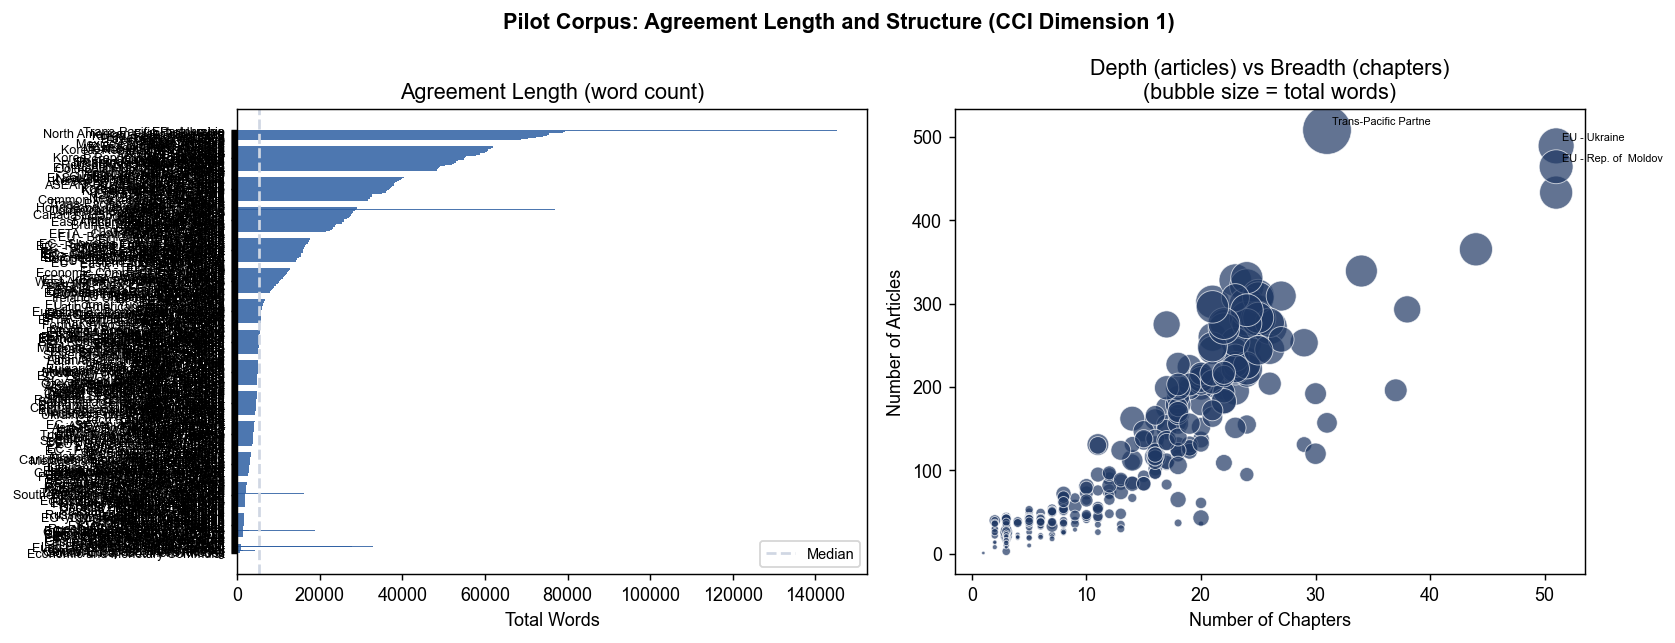

Figure 1 saved.


In [19]:
# ── Figure 1: Agreement length and chapter count ──────────────────────────────
# Justification: total word count and n_chapters are the D1 (Structure) component of CCI
# This figure directly motivates WHY length and structure matter for completeness

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Pilot Corpus: Agreement Length and Structure (CCI Dimension 1)',
             fontsize=12, fontweight='bold')

# Panel 1: Total words per agreement (sorted)
ax = axes[0]
sorted_words = df_agree_summary.sort_values('total_words', ascending=True)
short_names  = [n[:30] for n in sorted_words['agreement_name']]
ax.barh(short_names, sorted_words['total_words'], color='#2E5FA3', alpha=0.85)
ax.set_xlabel('Total Words')
ax.set_title('Agreement Length (word count)')
ax.tick_params(axis='y', labelsize=7)
ax.axvline(sorted_words['total_words'].median(), color='#D0D7E3',
           linestyle='--', linewidth=1.5, label='Median')
ax.legend(fontsize=8)

# Panel 2: Number of articles vs number of chapters (scatter)
ax = axes[1]
ax.scatter(df_agree_summary['n_chapters'], df_agree_summary['n_articles'],
           s=df_agree_summary['total_words'] / 200,  # bubble size = length
           c='#1F3864', alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Number of Chapters')
ax.set_ylabel('Number of Articles')
ax.set_title('Depth (articles) vs Breadth (chapters)\n(bubble size = total words)')

# Label a few points
for _, row in df_agree_summary.nlargest(3, 'n_articles').iterrows():
    ax.annotate(row['agreement_name'][:20],
                (row['n_chapters'], row['n_articles']),
                fontsize=6, ha='left', xytext=(3, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_agreement_structure.png'), bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


---
## Part 6: Text Pre-processing (Session 3 Pipeline)

**Pre-processing decisions to discuss explicitly in the paper:**

1. **Language handling (Option 2 — multilingual):** The ToTA corpus contains agreements in
   English, French, and Spanish. Rather than discarding non-English agreements (Option 1),
   we use language-appropriate stopword lists and stemmers for each. The `language` field
   in the ToTA XML drives this automatically. To revert to English-only, set
   `LANGUAGE_MODE = 'english_only'` in the first line of the cell below.

2. **No stemming before dictionary scoring:** We do not stem before computing the obligation
   dictionary — the raw form is more transparent and reproducible. Stemming is available
   as an option for frequency analysis only.

3. **Domain stopwords in all three languages:** On top of NLTK's standard lists, we add
   legal boilerplate terms (`party`, `agreement`, `partie`, `acuerdo`, etc.) that appear
   identically in every PTA and carry zero CCI signal.

4. **Article-level structure preserved:** All NLP runs at the article level and aggregates
   up, letting us score dispute-settlement chapters separately from market-access chapters.


In [22]:
# ── Language mode — toggle between Option 1 and Option 2 here ─────────────────
#
#   LANGUAGE_MODE = 'english_only'   # Option 1: drop non-English agreements (simpler)
#   LANGUAGE_MODE = 'multilingual'   # Option 2: language-aware NLP for all (default)
#
LANGUAGE_MODE = 'english_only'

# ── Add language column to df_articles (join from df_meta) ───────────────────
if 'language' not in df_articles.columns:
    df_articles = df_articles.merge(
        df_meta[['pta_id', 'language']], on='pta_id', how='left'
    )
df_articles['language'] = df_articles['language'].fillna('en')

# ── Option 1: English-only filter ────────────────────────────────────────────
if LANGUAGE_MODE == 'english_only':
    n_before    = len(df_articles)
    en_ptas     = set(df_meta[df_meta['language'] == 'en']['pta_id'])
    df_articles = df_articles[df_articles['pta_id'].isin(en_ptas)].reset_index(drop=True)
    print(f'Option 1 - English only: {len(en_ptas)} agreements, {len(df_articles)} articles')
    print(f'  (dropped {n_before - len(df_articles)} articles from non-English agreements)')
else:
    lang_counts = df_meta['language'].value_counts()
    print(f'Option 2 - Multilingual: {len(df_meta)} agreements total')
    print('  Language breakdown:')
    for lang, n in lang_counts.items():
        print(f'    {lang}: {n} agreements')


LAYER_0_ENGLISH_BASE = {
    # Articles & determiners
    "a", "an", "the",
    # Basic conjunctions (safe ones — "nor", "unless" removed)
    "and", "but", "or", "yet", "so",
    # Pronouns
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves",
    "you", "your", "yours", "yourself", "yourselves",
    "he", "him", "his", "himself", "she", "her", "hers", "herself",
    "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "who", "whom", "whose",
    # Prepositions (safe ones — directional/conditional ones kept)
    "of", "in", "to", "for", "on", "at", "by", "with", "about",
    "into", "through", "during", "above", "below", "from",
    "up", "down", "out", "off", "over", "under",
    # Auxiliaries (safe ones — "may", "shall", "must", "should" REMOVED)
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing",
    "will", "would", "would", "can", "could",
    # Common adverbs (safe to remove)
    "here", "there", "when", "how", "why",
    "very", "more", "most", "just", "now", "then", "again",
    "too", "quite", "rather", "already", "still", "once",
    # Demonstratives
    "this", "that", "these", "those",
    # Common filler words
    "accordingly", "thus", "hence", "therefore",
    "said", "same", "respectively",
}
# ===========================================================================
# LAYER 1 — Legal boilerplate with no discriminatory power
# These appear in nearly every PTA regardless of content or ambition.
# High corpus frequency, near-zero TF-IDF value across the 448 PTA corpus.
# Latin terms common in international legal drafting are included.
# ===========================================================================
 
LAYER_1_LEGAL_BOILERPLATE = {
    # Standard opening/closing formulas
    "whereas", "witnesseth", "now therefore",
    "in witness whereof", "done at", "done in",
    "in duplicate", "in triplicate",
    "signed", "concluded", "entered into",
 
    # Arcane referential language (zero content value)
    "hereof", "hereto", "hereunder", "hereafter", "hereby",
    "hereinafter", "hereinabove", "hereinbefore",
    "therein", "thereof", "thereto", "thereunder", "thereafter",
    "thereby", "therewith", "thereon",
    "wherein", "whereof", "whereto", "whereunder",
    "aforesaid", "aforementioned", "abovementioned",
    "above-mentioned", "aforegoing",
 
    # Latin legal phrases (boilerplate usage in PTAs)
    "inter alia", "mutatis mutandis", "sui generis", "de facto",
    "de jure", "ex officio", "prima facie", "bona fide",
    "ex ante", "ex post", "ad hoc", "pro rata",
    "vis-a-vis", "vis à vis", "et seq", "et al",
    "ibid", "idem", "supra", "infra",
 
    # Attestation and signature boilerplate
    "duly", "undersigned", "authorized", "authorised",
    "signatory", "signatories", "plenipotentiary", "plenipotentiaries",
    "ratification", "ratify", "ratified", "ratifying",
    "accession", "accede", "acceded",
    "entry into force", "come into force", "enter into force",
 
    # General legal reference words (no substantive content)
    "pursuant to", "pursuant", "in accordance with", "in accordance",
    "in conformity with", "consistent with",
    "notwithstanding the foregoing",  # "notwithstanding" alone is PROTECTED
    "as the case may be",
    "as appropriate",
    "as applicable",
 
    "in general",
    "inter alia",
 
    # Document reference words (structural, not substantive)
    "see", "refer", "referenced", "referring",
    "set forth", "set out", "laid down", "laid out",
    "contained in", "referred to in",
    "as defined in", "as provided in", "as specified in",
    "as described in", "as mentioned in",
    "as established in", "as determined in",
}
 
 
# ===========================================================================
# LAYER 2 — Trade agreement structural & procedural noise
# Formatting words, procedural terms, and WTO/PTA boilerplate that appear
# uniformly across all agreements — they describe *where* text is located
# or *how* the document is organized, not *what* it commits to.
#
# NOTE: "annex", "schedule", "appendix" are included here because the
# Alschner pipeline strips annexes. If you run a version WITH annexes,
# comment out that sub-group and re-run your CCS comparison.
# ===========================================================================
 
LAYER_2_TRADE_STRUCTURAL = {
    # Document structure words
    "chapter", "article", "paragraph", "subparagraph",
    "clause", "sub-clause", "subclause",
    "section", "subsection", "sub-section",
    "part", "title", "preamble",
    "page", "pages",
 
    # Annex/schedule group (see note above — comment out if including annexes)
    "annex", "annexes", "annex i", "annex ii", "annex iii",
    "schedule", "schedules", "appendix", "appendices",
    "attachment", "attachments", "exhibit", "exhibits",
 
    # Numbering & labelling
    "number", "numbers", "no.", "nos.",
    "item", "items", "list", "lists",
    "table", "tables", "figure", "figures",
    "footnote", "footnotes",
 
    # Standard procedural actors (appear in every PTA)
    "parties", "party", "member", "members",
    "contracting party", "contracting parties",
    "signatory parties", "signatory party",
    "member state", "member states",
    "the parties", "the party",
 
    # WTO/organization name boilerplate
    "world trade organization", "wto",
    "general agreement", "gatt", "gats", "trips",
    "world trade", "multilateral",
    "regional trade agreement", "free trade agreement",
    "preferential trade agreement",
    "pta", "rta", "fta",
 
    # Procedural/temporal markers (administrative, not substantive)
    "date", "dates", "dated",
    "year", "years", "month", "months", "day", "days",
    "calendar", "fiscal",
    "enter", "entry",
    "force", "effect", "effective",
    "amendment", "amendments", "amend", "amended",
    "modification", "modifications", "modify", "modified",
    "revision", "revisions", "revise", "revised",
    "review", "reviews",  # BUT "reviewed" can signal enforcement — watch
    "renewal", "renew", "renewed",
    "termination", "terminate", "terminated",
    "withdrawal", "withdraw", "withdrawn",
    "notification", "notify", "notified", "notifying",
    "communication", "communicate",
    "publish", "published",
    "deposit", "depositary", "deposited",
 
    # Generic administrative verbs (too diffuse to carry CCS signal)
    "agree", "agreed", "agreement",  # ironic, but too generic
    "establish", "established", "establishment",
    "constitute", "constituted", "constitution",
    "create", "created",
    "form", "formed", "formation",
    "adopt", "adopted", "adoption",
    "apply", "applied", "application",
    "implement", "implemented", "implementation",
    "determine", "determined", "determination",
    "consider", "considered", "consideration",
    "decide", "decided", "decision",
    "recognize", "recognised", "recognized", "recognition",
    "acknowledge", "acknowledged",
    "confirm", "confirmed", "confirmation",
    "note", "noted", "noting",
    "recall", "recalled", "recalling",
 
    # Country/territory reference fillers
    "territory", "territories", "territorial",
    "jurisdiction", "jurisdictions",
    "domestic", "national", "international",
    "bilateral", "plurilateral",
 
    # Common trade policy qualifiers (near-universal, low discriminatory value)
    "trade", "goods", "services",  # too broad — keep only in context
    "market", "markets",
    "customs", "duty", "duties",
    "tariff", "tariffs",
    "quota", "quotas",
}
 
 
# ===========================================================================
# LAYER 3 — PROTECTED TERMS
# These are CCS index signals. NEVER add to the active stopword set.
# They measure: obligation density, conditionality, precision, enforcement.
#
# This set is used for validation only — run an assertion check to ensure
# none of these appear in your active stopword set.
# ===========================================================================
 
LAYER_3_PROTECT = {
    # ---- Obligation markers (hard) ----
    "shall", "must", "is required", "are required",
    "required to", "obliged to", "obligated to",
    "undertakes to", "undertake to", "undertakes",
    "commits to", "commit to", "commits",
    "binds", "bound to", "bound by",
 
    # ---- Soft-language / best-endeavour markers ----
    "should", "endeavour", "endeavor",
    "endeavours", "endeavors",
    "encourage", "encourages", "encouraged",
    "promote", "promotes", "promoted",
    "seek to", "seeks to",
    "strive", "strives", "strive to",
    "aim", "aims", "aim to",
    "facilitate", "facilitates",
    "cooperate", "cooperates", "cooperation",
    "recommend", "recommends",
 
    # ---- Conditionality triggers ----
    "if", "unless", "except", "except where",
    "provided that", "provided however",
    "subject to", "notwithstanding",
    "without prejudice to",
    "in the event", "in the event that",
    "where", "where applicable",
    "in so far as", "insofar as",
    "to the extent that", "to the extent",
 
    # ---- Scope qualifiers (precision indicators) ----
    "all", "each", "every", "any", "no",
    "only", "solely", "exclusively",
    "generally", "specifically",
    "not", "nor", "never",
    "both", "either", "neither",
    "other", "otherwise",
    "further", "furthermore",
    "also", "in addition", "additionally",
    "including", "includes", "include",
    "such as", "namely", "in particular",
    "without limitation", "without limiting",
 
    # ---- Enforcement & dispute settlement ----
    "remedy", "remedies", "remedial",
    "sanction", "sanctions",
    "penalty", "penalties", "penalize", "penalise",
    "compensation", "compensate", "compensatory",
    "retaliate", "retaliation", "retaliatory",
    "suspend", "suspension", "suspended",
    "safeguard", "safeguards",
    "countermeasure", "countermeasures",
    "enforce", "enforcement", "enforced", "enforceable",
    "comply", "compliance", "complies", "non-compliance",
    "violation", "violate", "violates",
    "breach", "breaches",
    "arbitration", "arbitral", "arbitrator",
    "panel", "panels", "panelist",
    "appellate", "appeal", "appeals",
    "ruling", "rulings",
    "finding", "findings",
    "dispute", "disputes",
    "settlement", "settle", "settles",
    "consultations", "consult", "consults",
    "good offices", "mediation", "mediator",
    "binding", "non-binding",
    "final", "finality",
 
    # ---- Legal precision markers ----
    "define", "defined", "definition", "definitions",
    "means", "meaning",
    "refers", "reference",
    "herein", # debated — keep protected since "as defined herein" scopes obligations
    "timeline", "timelines", "timeframe", "time frame",
    "within", "no later than", "not later than",
    "deadline", "deadlines",
    "period", "periods",
 
    # ---- Issue area coverage (binary provision indicators) ----
    "investment", "investor", "investors",
    "intellectual property", "copyright", "patent", "trademark",
    "competition", "anti-competitive", "monopoly",
    "procurement", "procuring entity",
    "labor", "labour", "workers", "employment",
    "environment", "environmental",
    "data", "privacy", "personal data",
    "digital", "electronic commerce", "e-commerce",
    "financial services", "banking", "insurance",
    "telecommunications", "telecom",
    "transparency", "publication",
    "regulatory", "regulation", "regulations",
    "standard", "standards", "standardization",
    "technical barrier", "tbt",
    "sanitary", "phytosanitary", "sps",
    "rules of origin", "origin",
    "subsidies", "subsidy", "countervailing",
    "anti-dumping", "dumping",
    "state-owned enterprise", "soe",
    "currency", "exchange rate", "monetary",
}
 
# ===========================================================================
# PUBLIC API
# ===========================================================================
 
def get_stopwords(
    layers: list = None,
    extra: set = None,
    validate: bool = True
) -> set:
    """
    Return the active stopword set for PTA preprocessing.
 
    Parameters
    ----------
    layers : list of int, optional
        Which layers to include. Default is [0, 1, 2] (all removal layers).
        Options: 0 = English base, 1 = legal boilerplate, 2 = trade structural.
        Do NOT include 3 — Layer 3 is the protected set, not for removal.
 
    extra : set, optional
        Additional domain-specific words to add to the stopword set.
        These are NOT checked against LAYER_3_PROTECT — you are responsible
        for not adding protected terms here.
 
    validate : bool, optional
        If True (default), raises AssertionError if any LAYER_3_PROTECT term
        ends up in the final stopword set. Highly recommended to keep True.
 
    Returns
    -------
    set of str
        Lowercase stopword set ready for token filtering.
 
    Examples
    --------
    >>> sw = get_stopwords()
    >>> tokens = ["the", "parties", "shall", "endeavour", "to", "cooperate"]
    >>> filtered = [t for t in tokens if t.lower() not in sw]
    >>> # filtered = ["shall", "endeavour", "cooperate"]
    # Note: "to" removed (Layer 0), "the"/"parties" removed (Layer 0/2)
    # "shall", "endeavour", "cooperate" RETAINED (Layer 3 protected)
    """
    if layers is None:
        layers = [0, 1, 2]
 
    layer_map = {
        0: LAYER_0_ENGLISH_BASE,
        1: LAYER_1_LEGAL_BOILERPLATE,
        2: LAYER_2_TRADE_STRUCTURAL,
    }
 
    active = set()
    for layer_id in layers:
        if layer_id not in layer_map:
            raise ValueError(
                f"Layer {layer_id} not valid. Choose from 0, 1, 2. "
                f"Layer 3 is LAYER_3_PROTECT and is never added to stopwords."
            )
        active.update(layer_map[layer_id])
 
    if extra:
        active.update({w.lower() for w in extra})
 
    if validate:
        leaked = active.intersection(LAYER_3_PROTECT)
        if leaked:
            raise AssertionError(
                f"Protected CCS signal terms found in stopword set: {leaked}\n"
                f"Remove these from your custom additions or check layer definitions."
            )
 
    return active
 
 
def describe_layers() -> None:
    """Print a summary of each layer with word counts."""
    print("=" * 60)
    print("TRADE AGREEMENT STOPWORD LAYERS — SUMMARY")
    print("=" * 60)
    layers = [
        ("Layer 0 — English base (pruned)",   LAYER_0_ENGLISH_BASE,      "REMOVE"),
        ("Layer 1 — Legal boilerplate",        LAYER_1_LEGAL_BOILERPLATE, "REMOVE"),
        ("Layer 2 — Trade structural noise",   LAYER_2_TRADE_STRUCTURAL,  "REMOVE"),
        ("Layer 3 — CCS signal terms (KEEP)",  LAYER_3_PROTECT,           "PROTECT"),
    ]
    for name, layer, action in layers:
        print(f"\n  {name}")
        print(f"  Action : {action}")
        print(f"  Words  : {len(layer)}")
    total_remove = len(LAYER_0_ENGLISH_BASE | LAYER_1_LEGAL_BOILERPLATE | LAYER_2_TRADE_STRUCTURAL)
    print(f"\n  Total active stopwords (all removal layers): {total_remove}")
    print(f"  Total protected CCS signal terms          : {len(LAYER_3_PROTECT)}")
    print("=" * 60)
 
 
def check_word(word: str) -> str:
    """
    Diagnostic: tell you which layer a given word belongs to.
 
    Parameters
    ----------
    word : str
        A word or phrase to look up (case-insensitive).
 
    Returns
    -------
    str
        Description of the layer(s) the word appears in.
    """
    w = word.lower().strip()
    found = []
    if w in LAYER_0_ENGLISH_BASE:
        found.append("Layer 0 — English base (REMOVED)")
    if w in LAYER_1_LEGAL_BOILERPLATE:
        found.append("Layer 1 — Legal boilerplate (REMOVED)")
    if w in LAYER_2_TRADE_STRUCTURAL:
        found.append("Layer 2 — Trade structural (REMOVED)")
    if w in LAYER_3_PROTECT:
        found.append("Layer 3 — CCS signal (PROTECTED — never remove)")
    if not found:
        return f"'{word}' not found in any layer (treat as content word, keep by default)"
    return f"'{word}' → " + "; ".join(found)
 
 
# ===========================================================================
# QUICK DEMO — run python trade_stopwords.py
# ===========================================================================
 
if __name__ == "__main__":
    describe_layers()
 
    print("\n--- Layer check examples ---")
    test_words = [
        "shall", "must", "whereas", "hereinafter", "parties",
        "article", "endeavour", "notwithstanding", "arbitration",
        "annex", "chapter", "the", "dispute", "compliance",
        "provided that", "subject to", "mutatis mutandis",
        "territory", "investment", "wto", "remedy", "tariff",
    ]
    for w in test_words:
        print(f"  {check_word(w)}")
 
    print("\n--- Filtering demo ---")
    sample_sentence = (
        "the parties shall endeavour to ensure compliance with "
        "the provisions set forth herein and shall establish "
        "an arbitration panel pursuant to annex i of this agreement"
    )
    sw = get_stopwords()
    tokens = sample_sentence.lower().split()
    filtered = [t for t in tokens if t not in sw]
    print(f"  Original : {sample_sentence}")
    print(f"  Filtered : {' '.join(filtered)}")
    print(f"  (Kept 'shall', 'endeavour', 'compliance', 'provisions',")
    print(f"   'arbitration', 'panel' — removed structural/boilerplate noise)")


# ── Helper functions ──────────────────────────────────────────────────────────
def strip_punct(word):
    return re.sub(r'\W+', '', word)

def abbr_or_lower(word):
    """Keep abbreviations uppercase (WTO, FTA, IP), lowercase everything else."""
    if re.match(r'([A-Z]+[a-z]*){2,}', word):
        return word
    return word.lower()

def preprocess(text, lang='en', remove_stops=True, stem=False):
    """
    Tokenise and clean one article string.
    lang: 'en', 'fr', or 'es' — selects the right stopword list and stemmer.
    """
    stops   = STOP_CONFIG.get(lang, STOP_CONFIG['en'])
    stemmer = STEMMER_CONFIG.get(lang, STEMMER_CONFIG['en'])
    words   = text.split()
    tokens  = [abbr_or_lower(strip_punct(w)) for w in words]
    tokens  = [t for t in tokens if len(t) > 1]
    if remove_stops:
        tokens = [t for t in tokens if t.lower() not in stops]
    if stem:
        tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# # ── Apply with language awareness ────────────────────────────────────────────
# df_articles['tokens'] = df_articles.apply(
#     lambda row: preprocess(row['article_text'], lang=row['language'],
#                            remove_stops=True, stem=False), axis=1
# )
# df_articles['tokens_stemmed'] = df_articles.apply(
#     lambda row: preprocess(row['article_text'], lang=row['language'],
#                            remove_stops=True, stem=True), axis=1
# )
# df_articles['token_count'] = df_articles['tokens'].apply(len)

# # # ── Summary ───────────────────────────────────────────────────────────────────
# print(f'\nPre-processing done.')
# for lang, label in [('en','English'), ('fr','French'), ('es','Spanish')]:
#     subset = df_articles[df_articles['language'] == lang]
#     if len(subset) > 0:
#         print(f'  [{lang}] {len(subset):,} articles | '
#               f'avg tokens after removal: {subset["token_count"].mean():.0f} | '
#               f'stopwords used: {len(STOP_CONFIG[lang])}')


Option 1 - English only: 424 agreements, 35479 articles
  (dropped 0 articles from non-English agreements)
TRADE AGREEMENT STOPWORD LAYERS — SUMMARY

  Layer 0 — English base (pruned)
  Action : REMOVE
  Words  : 110

  Layer 1 — Legal boilerplate
  Action : REMOVE
  Words  : 102

  Layer 2 — Trade structural noise
  Action : REMOVE
  Words  : 187

  Layer 3 — CCS signal terms (KEEP)
  Action : PROTECT
  Words  : 227

  Total active stopwords (all removal layers): 399
  Total protected CCS signal terms          : 227

--- Layer check examples ---
  'shall' → Layer 3 — CCS signal (PROTECTED — never remove)
  'must' → Layer 3 — CCS signal (PROTECTED — never remove)
  'whereas' → Layer 1 — Legal boilerplate (REMOVED)
  'hereinafter' → Layer 1 — Legal boilerplate (REMOVED)
  'parties' → Layer 2 — Trade structural (REMOVED)
  'article' → Layer 2 — Trade structural (REMOVED)
  'endeavour' → Layer 3 — CCS signal (PROTECTED — never remove)
  'notwithstanding' → Layer 3 — CCS signal (PROTECTED 

In [23]:
# ── Figure 2: Pre-processing comparison — what changes when we remove stopwords?
# This directly addresses the professor's instruction:
# 'pay special attention to pre-processing steps and show what changes'

all_tokens_raw   = [t for tokens in df_articles['article_text'].apply(
    lambda t: preprocess(t, remove_stops=False)) for t in tokens]
all_tokens_clean = [t for tokens in df_articles['tokens'] for t in tokens]

freq_raw   = Counter(all_tokens_raw).most_common(20)
freq_clean = Counter(all_tokens_clean).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Pre-processing on Term Frequency\n'
             '(domain stopword list removes treaty boilerplate)',
             fontsize=11, fontweight='bold')

for ax, (freq, title, col) in zip(axes, [
    (freq_raw,   'With stopwords',                               '#D0D7E3'),
    (freq_clean, 'After removal (standard + domain stopwords)',  '#2E5FA3')
]):
    words, counts = zip(*freq)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=col, alpha=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_preprocessing_comparison.png'), bbox_inches='tight')
plt.show()
print("Figure 2 saved.")
print("Note: After domain stopword removal, obligation terms (shall, trade, tariff)")
print("dominate — which is exactly what we want for the CCI.")

NameError: name 'STOP_CONFIG' is not defined


---
## Part 7: CCI Dictionary Measures

This is the core NLP contribution: counting **hard obligation** vs **soft/aspirational** language,
and **enforcement/dispute-settlement** terms — all normalized per 1,000 words.

This directly mirrors the EPU dictionary approach from Sessions 5–6: define term lists,
count frequency, normalize. The normalized score is the measure.

### Trilingual dictionaries
Each term list contains English, French, and Spanish equivalents. The `dict_score` function
selects the right list based on the `language` field of each article — so a French agreement
is scored against French obligation terms, not English ones.

| Dimension | English examples | French examples | Spanish examples |
|---|---|---|---|
| Hard obligation | shall, must | doit, devra | deberá, debe |
| Soft obligation | should, endeavour | devrait, s'efforcera | debería, procurará |
| Enforcement | dispute, arbitration | différend, arbitrage | controversia, arbitraje |


In [ ]:
# ── Obligation and enforcement dictionaries — trilingual ──────────────────────
# Each key is a language code ('en', 'fr', 'es').
# dict_score() selects the right list per article based on df_articles['language'].

OBLIGATION_HARD = {
    'en': [
        'shall', 'must', 'required', 'obliged', 'obligated',
        'is required', 'are required', 'shall ensure', 'must ensure',
        'is prohibited', 'are prohibited', 'will ensure',
    ],
    'fr': [
        'doit', 'devra', 'doivent', 'devront',
        'est tenu', 'sont tenus', 'est obligé', 'sont obligés',
        'doit assurer', 'doivent assurer', 'veillera', 'veilleront',
        'est interdit', 'sont interdits',
    ],
    'es': [
        'deberá', 'deberán', 'debe', 'deben',
        'se obliga', 'se obligan', 'es obligatorio', 'son obligatorios',
        'deberá garantizar', 'deberán garantizar',
        'está prohibido', 'están prohibidos', 'velará', 'velarán',
    ],
}

OBLIGATION_SOFT = {
    'en': [
        'should', 'endeavour', 'endeavor', 'encourage', 'promote',
        'best efforts', 'as appropriate', 'where possible',
        'where feasible', 'to the extent possible',
        'seek to', 'consider', 'may',
    ],
    'fr': [
        'devrait', 'devraient', "s'efforcera", "s'efforceront",
        'encourage', 'favorise', 'promouvoir', "selon qu'il convient",
        "dans la mesure du possible", "dans toute la mesure possible",
        "cherchera à", 'peut', 'pourra', "meilleurs efforts",
    ],
    'es': [
        'debería', 'deberían', 'procurará', 'procurarán',
        'alentará', 'promoverá', 'fomentará',
        'según corresponda', 'en la medida de lo posible',
        'en la mayor medida posible', 'podrá', 'podrán',
        'mejores esfuerzos', 'cuando sea factible',
    ],
}

ENFORCEMENT = {
    'en': [
        'dispute', 'arbitration', 'panel', 'tribunal', 'remedy',
        'sanction', 'compensation', 'retaliation', 'suspension',
        'binding', 'ruling', 'award', 'compliance', 'days',
    ],
    'fr': [
        'différend', 'differend', 'arbitrage', "groupe spécial", 'tribunal',
        'recours', 'sanction', 'compensation', "rétorsion", 'retorsion',
        'suspension', 'contraignant', "décision", 'decision',
        "sentence", "conformité", 'conformite', 'jours',
    ],
    'es': [
        'controversia', 'arbitraje', 'panel', 'tribunal', 'recurso',
        'sanción', 'sancion', 'compensación', 'compensacion',
        'suspensión', 'suspension', 'vinculante', 'resolución',
        'resolucion', 'laudo', 'cumplimiento', 'días', 'dias',
    ],
}

def dict_score(text, dictionary, lang='en'):
    """
    Count dictionary term hits in text, normalized per 1,000 words.
    Uses the language-appropriate term list (falls back to English if lang unknown).
    Returns (raw_count, per_1000_words).
    """
    terms      = dictionary.get(lang, dictionary['en'])
    text_lower = text.lower()
    n_words    = len(text.split())
    raw        = sum(text_lower.count(term) for term in terms)
    per1000    = (raw / n_words * 1000) if n_words > 0 else 0
    return raw, per1000

# ── Apply with language awareness ─────────────────────────────────────────────
df_articles[['hard_raw', 'hard_p1k']] = df_articles.apply(
    lambda row: pd.Series(dict_score(row['article_text'], OBLIGATION_HARD, row['language'])),
    axis=1
)
df_articles[['soft_raw', 'soft_p1k']] = df_articles.apply(
    lambda row: pd.Series(dict_score(row['article_text'], OBLIGATION_SOFT, row['language'])),
    axis=1
)
df_articles[['enf_raw', 'enf_p1k']] = df_articles.apply(
    lambda row: pd.Series(dict_score(row['article_text'], ENFORCEMENT, row['language'])),
    axis=1
)

# Obligation ratio: hard / (soft + 1) — completeness signal per article
df_articles['oblig_ratio'] = df_articles['hard_raw'] / (df_articles['soft_raw'] + 1)

# ── Summary by language ────────────────────────────────────────────────────────
print("Dictionary scoring done.")
print("\nMean scores by language (sanity check — should be in similar ballpark):")
for lang in ['en', 'fr', 'es']:
    subset = df_articles[df_articles['language'] == lang]
    if len(subset) > 0:
        print(f"  [{lang}] hard_p1k: {subset['hard_p1k'].mean():.2f}  "
              f"soft_p1k: {subset['soft_p1k'].mean():.2f}  "
              f"enf_p1k: {subset['enf_p1k'].mean():.2f}  "
              f"n_articles: {len(subset):,}")

print("\nSample scores:")
print(df_articles[['language', 'chapter_name', 'article_name',
                    'hard_p1k', 'soft_p1k', 'enf_p1k', 'oblig_ratio']]
      .head(8).to_string(index=False))


In [ ]:
# ── Agreement-level CCI (pilot version: D1 + D3 only) ────────────────────────
# D1 = length/structure, D3 = obligation depth
# D2 (breadth/chapter coverage) and D4 (DS detail) added once full corpus available

from sklearn.preprocessing import MinMaxScaler

def w_mean(g, val, wt):
    """Length-weighted mean across articles."""
    return (g[val] * g[wt]).sum() / g[wt].sum() if g[wt].sum() > 0 else 0

df_cci = df_articles.groupby(['pta_id', 'agreement_name', 'year']).apply(
    lambda g: pd.Series({
        'total_words':    g['word_count'].sum(),
        'n_articles':     len(g),
        'n_chapters':     g['chapter_name'].nunique(),
        'hard_p1k_mean':  w_mean(g, 'hard_p1k', 'word_count'),
        'soft_p1k_mean':  w_mean(g, 'soft_p1k', 'word_count'),
        'enf_p1k_mean':   w_mean(g, 'enf_p1k',  'word_count'),
        'oblig_ratio':    w_mean(g, 'oblig_ratio', 'word_count'),
    })
).reset_index()

df_cci['year'] = pd.to_numeric(df_cci['year'], errors='coerce')

# Normalize each dimension to [0, 1]
scaler = MinMaxScaler()
dims   = ['total_words', 'n_articles', 'hard_p1k_mean', 'enf_p1k_mean']
norms  = [d + '_norm' for d in dims]
df_cci[norms] = scaler.fit_transform(df_cci[dims])

# Baseline CCI: equal weight on D1 (0.25) and D3 components (0.50) and enforcement (0.25)
# Weights from proposal: w1=0.15 (length), w2=0.25 (breadth), w3=0.30 (obligations), w4=0.30 (DS)
# Here, without D2 and D4, we rescale: length 0.25, n_articles 0.25, obligations 0.25, enforcement 0.25
df_cci['CCI_pilot'] = (
    0.25 * df_cci['total_words_norm'] +
    0.25 * df_cci['n_articles_norm']  +
    0.25 * df_cci['hard_p1k_mean_norm'] +
    0.25 * df_cci['enf_p1k_mean_norm']
)

print("CCI (pilot) computed. Rankings:")
print(df_cci[['agreement_name', 'year', 'n_chapters', 'n_articles',
              'hard_p1k_mean', 'enf_p1k_mean', 'CCI_pilot']]
      .sort_values('CCI_pilot', ascending=False).to_string(index=False))

In [ ]:
# ── Figure 3: CCI rankings and component breakdown ────────────────────────────
# This is the key 'results' figure — directly answers the research question

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pilot Contract Completeness Index (CCI)\n'
             'Dimensions: Length + Article count + Obligation density + Enforcement density',
             fontsize=11, fontweight='bold')

# Panel 1: CCI ranking bar chart
ax = axes[0]
df_sorted = df_cci.sort_values('CCI_pilot', ascending=True)
short_names = [n[:32] for n in df_sorted['agreement_name']]
colors = ['#1F3864' if s > df_cci['CCI_pilot'].median() else '#2E5FA3'
          for s in df_sorted['CCI_pilot']]
ax.barh(short_names, df_sorted['CCI_pilot'], color=colors, alpha=0.85)
ax.axvline(df_cci['CCI_pilot'].median(), color='#D0D7E3',
           linestyle='--', linewidth=1.5, label='Median')
ax.set_xlabel('CCI Score (0 = least complete, 1 = most complete)')
ax.set_title('Contract Completeness Index Rankings')
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=8)

# Panel 2: Hard vs soft obligation density scatter — the obligation ratio
ax = axes[1]
sc = ax.scatter(
    df_cci['soft_p1k_mean'],
    df_cci['hard_p1k_mean'],
    s=df_cci['total_words'] / 100,       # bubble = length
    c=df_cci['CCI_pilot'], cmap='Blues',
    alpha=0.85, edgecolors='#1F3864', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='CCI Score')
# Reference line: equal hard/soft
lim = max(df_cci['soft_p1k_mean'].max(), df_cci['hard_p1k_mean'].max()) + 1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='Hard = Soft')

for _, row in df_cci.nlargest(3, 'hard_p1k_mean').iterrows():
    ax.annotate(row['agreement_name'][:22],
                (row['soft_p1k_mean'], row['hard_p1k_mean']),
                fontsize=6, xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Soft obligation density (per 1,000 words)')
ax.set_ylabel('Hard obligation density (per 1,000 words)')
ax.set_title('Hard vs. Soft Obligation Language\n(bubble size = total words)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_cci_rankings.png'), bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

In [ ]:
# ── Figure 4: CCI by chapter type — which chapters drive completeness? ─────────
# Justification: shows where the CCI signal is coming from within agreements
# Key insight for paper: dispute-settlement chapters should have highest obligation density

chapter_stats = df_articles.groupby('chapter_name').agg(
    n_articles     = ('article_text', 'count'),
    avg_hard_p1k   = ('hard_p1k', 'mean'),
    avg_soft_p1k   = ('soft_p1k', 'mean'),
    avg_enf_p1k    = ('enf_p1k',  'mean'),
    avg_oblig_ratio= ('oblig_ratio', 'mean')
).reset_index()

# Keep chapters with at least 2 articles across corpus
chapter_stats = chapter_stats[chapter_stats['n_articles'] >= 2]
chapter_stats = chapter_stats.sort_values('avg_hard_p1k', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
short_ch = [c[:35] for c in chapter_stats['chapter_name']]
width = 0.35
x = range(len(chapter_stats))

ax.barh([i - width/2 for i in x], chapter_stats['avg_hard_p1k'],
        height=width, label='Hard (shall/must)', color='#1F3864', alpha=0.85)
ax.barh([i + width/2 for i in x], chapter_stats['avg_soft_p1k'],
        height=width, label='Soft (should/endeavour)', color='#D0D7E3', alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(short_ch, fontsize=8)
ax.set_xlabel('Average frequency per 1,000 words')
ax.set_title('Obligation Language Density by Chapter Type\n'
             '(Hard vs. Soft — averaged across all pilot agreements)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_chapter_obligation_density.png'), bbox_inches='tight')
plt.show()
print("Figure 4 saved.")
print("Expected pattern: Dispute Settlement chapters should have highest hard/soft ratio.")


---
## Part 8: Automated Hybrid — Link ToTA to WTO Metadata (No Manual Downloads)

### Short answer: No, you do not have to manually download anything.

The ToTA XML already contains the WTO link in each agreement's `<source>` field, e.g.:

```
https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid=184
```

This means the hybrid pipeline is **fully automated** in four steps:

| Step | Task | Method |
|------|------|--------|
| 1 | Download ToTA texts | GitHub JSON API (Part 4 above) |
| 2 | Extract `rtaid` from `<source>` URL | `re.search(r'rtaid=(\d+)', source_url)` |
| 3 | Scrape WTO card page for metadata | `requests.get(url)` — plain GET, no ViewState |
| 4 | Merge text corpus with WTO metadata | `df_meta.merge(df_wto_cards, on='wto_rtaid')` |

### Why are WTO card pages easy when the search page was hard?

The WTO **search page** (`PublicSearchByCr.aspx`) is an ASP.NET WebForms page — it requires a GET to extract hidden `__VIEWSTATE` tokens, followed by a POST. That is what makes it "Medium-Hard" (see `scraping_WTO_portal.ipynb`).

The WTO **card pages** (`PublicShowRTAIDCard.aspx?rtaid=N`) are plain static HTML — one GET request with a URL parameter is all you need. This is identical in difficulty to the UN resolution downloads from class.

Because we get the `rtaid` directly from the ToTA `<source>` field, we never have to touch the search/list page at all.

### What metadata do WTO card pages provide?

Typical fields: full agreement title, type (FTA / Customs Union / EIA), parties, date of signature, date of entry into force, current status, coverage (goods / services / both). These are the exact variables needed to code the Antràs–Helpman institutional dummies in the regression.


In [ ]:

# ── Step 1 (setup): Additional import and WTO base URL ───────────────────────
# beautifulsoup4 is already in pyproject.toml — import it here for card parsing

from bs4 import BeautifulSoup   # already available: pip install beautifulsoup4

WTO_CARD_BASE = "https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid="

# ── Why are card pages easy when the search page was hard? ───────────────────
#
#  WTO SEARCH PAGE  (PublicSearchByCr.aspx)   ← scraping_WTO_portal.ipynb
#    - ASP.NET WebForms with __VIEWSTATE, __EVENTVALIDATION tokens
#    - Requires: GET page → extract hidden tokens → POST with tokens
#    - Difficulty: Medium-Hard
#
#  WTO CARD PAGE    (PublicShowRTAIDCard.aspx?rtaid=N)   ← this notebook
#    - Plain static HTML, one URL parameter
#    - Requires: requests.get(url)  ← that's it
#    - Difficulty: Easy (same as the UN resolutions class exercise)
#
# We get the rtaid for free from the ToTA XML <source> field — no search needed.

print(f"WTO card base URL: {WTO_CARD_BASE}")
print()
print("Hybrid strategy — 4 automated steps, zero manual downloads:")
print("  Step 1  Download ToTA corpus via GitHub API        (Part 4 above)")
print("  Step 2  extract_wto_rtaid(source_url) → rtaid      (regex on <source>)")
print("  Step 3  scrape_wto_card(rtaid)         → metadata  (plain GET, no ViewState)")
print("  Step 4  df_meta.merge(df_wto_cards)    → master    (pandas merge)")


In [ ]:

def extract_wto_rtaid(source_url):
    """
    Extracts the WTO rtaid integer from a ToTA <source> URL.

    Each ToTA XML file's <meta><source> field typically contains a WTO card URL:
        'https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid=184'

    We extract the rtaid with a simple regex — no network request needed.

    Args:
        source_url: string (the raw <source> text from ToTA XML)

    Returns:
        int  rtaid if found
        None if the source is blank, a different URL, or has no rtaid parameter
    """
    match = re.search(r'rtaid=(\d+)', str(source_url), re.IGNORECASE)
    return int(match.group(1)) if match else None


# ── Quick test ────────────────────────────────────────────────────────────────
test_cases = [
    ('https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid=184',  184),
    ('https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid=42',    42),
    ('http://www.fta.gov.sg/fta_sinaus.html',                        None),  # no rtaid
    ('',                                                              None),  # empty
]

print("extract_wto_rtaid() unit tests:")
all_passed = True
for url, expected in test_cases:
    got    = extract_wto_rtaid(url)
    status = '✓' if got == expected else '✗'
    if got != expected:
        all_passed = False
    print(f"  {status}  {url[:55]:55}  →  {got}  (expected {expected})")

print(f"\nAll tests passed: {all_passed}")


In [ ]:

def scrape_wto_card(rta_id, session=None):
    """
    Scrape metadata from one WTO RTA card page.
    
    URL pattern: https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid=<N>
    
    These pages are static read-only views — a plain GET is all that's needed.
    No ASP.NET ViewState, no POST, no session tokens (unlike the search page).
    
    Args:
        rta_id:  integer WTO rtaid
        session: optional requests.Session (use for connection pooling in loops)
    
    Returns:
        dict with {'wto_rta_id': rta_id, 'wto_card_url': url, <field>: <value>, ...}
        or None if the request fails.
    
    Typical fields returned by WTO card pages:
        full_title, type_of_agreement, date_of_signature, date_of_entry_into_force,
        coverage, current_status, parties, ...
    """
    url = WTO_CARD_BASE + str(rta_id)

    try:
        req = session if session else requests
        r   = req.get(url, timeout=20)
        r.raise_for_status()
    except Exception as e:
        print(f"  Error fetching rtaid={rta_id}: {e}")
        return None

    soup   = BeautifulSoup(r.text, 'html.parser')
    record = {'wto_rta_id': rta_id, 'wto_card_url': url}

    # Extract all <tr> rows with exactly 2 cells (label + value)
    # WTO card pages use a simple HTML table — no JavaScript rendering needed
    for row in soup.find_all('tr'):
        cells = row.find_all(['td', 'th'])
        if len(cells) == 2:
            # Normalise key: lowercase, non-alphanumeric → underscore
            key = re.sub(r'[^a-z0-9]+', '_',
                         cells[0].get_text(strip=True).lower()).strip('_')
            val = cells[1].get_text(separator=' ', strip=True)
            if key:
                record[key] = val

    return record


# ── Quick test on one known rtaid ─────────────────────────────────────────────
print("Testing scrape_wto_card(184) ...")
test_record = scrape_wto_card(184)
if test_record:
    print(f"Fields extracted: {len(test_record)}")
    for k, v in list(test_record.items())[:12]:
        print(f"  {k:35} {str(v)[:70]}")
else:
    print("Note: WTO portal not reachable from this environment.")
    print("The function is ready — it will work when run on your local machine.")


In [ ]:

# ── Step 2: wto_rta_id is already in df_meta — no extraction needed ──────────
# The ToTA XML has <wto_rta_id>1</wto_rta_id> directly in <meta>.
# parse_tota_xml already reads it as an integer, so df_meta['wto_rta_id']
# is ready to use immediately. No URL parsing or regex needed.

n_linked   = df_meta['wto_rta_id'].notna().sum()
n_total    = len(df_meta)

print(f"ToTA agreements in pilot corpus: {n_total}")
print(f"  With WTO rta_id:   {n_linked}  ({100*n_linked/n_total:.0f}% linked)" if n_total else "")
print(f"  Without WTO rta_id:{n_total - n_linked}")
print()
print("Sample wto_rta_id values (read directly from XML, no scraping):")
print(df_meta[['pta_id', 'name', 'wto_rta_id', 'status', 'type']].head(10).to_string(index=False))


In [ ]:

# ── Step 3: Scrape WTO card pages for all matched RTAs ───────────────────────
# Each card page is a simple GET request — no ViewState, no session tokens needed.
# We use requests.Session() for connection pooling (faster than opening a new
# connection for every request).

wto_session = requests.Session()
wto_session.headers.update(HEADERS)
wto_records = []
wto_errors  = []

rta_ids_to_scrape = df_meta['wto_rta_id'].dropna().astype(int).tolist()
print(f"WTO card pages to fetch: {len(rta_ids_to_scrape)}")
print("(One GET per agreement — no POST, no ViewState tokens)")
print()

for i, rta_id in enumerate(rta_ids_to_scrape):
    record = scrape_wto_card(rta_id, wto_session)
    if record:
        wto_records.append(record)
    else:
        wto_errors.append(rta_id)

    if (i + 1) % 10 == 0 or i < 3:
        status = 'OK' if record else 'FAILED'
        print(f"[{i+1:3}/{len(rta_ids_to_scrape)}]  rtaid={rta_id:4}  {status}  "
              f"collected so far: {len(wto_records)}")

    time.sleep(0.5)   # polite crawl delay — same as class convention

print(f"\nDone.")
print(f"  Scraped successfully: {len(wto_records)}")
print(f"  Errors:               {len(wto_errors)}")
if wto_errors:
    print(f"  Failed rtaids:        {wto_errors[:10]}")


In [ ]:

# ── Step 4: Merge WTO metadata into main CCI table ───────────────────────────

df_wto_cards = pd.DataFrame(wto_records)
print(f"\nWTO card data collected: {len(df_wto_cards)} records")
if not df_wto_cards.empty:
    print(df_wto_cards.head(3).to_string(index=False))

# Merge on wto_rtaid (left join: keep all ToTA agreements, add WTO fields where available)
df_master_meta = df_meta.merge(df_wto_cards, on='wto_rta_id', how='left')

n_matched = df_master_meta['wto_rta_id'].notna().sum()
print(f"\n{'='*60}")
print(f"HYBRID PIPELINE SUMMARY")
print(f"{'='*60}")
print(f"  ToTA agreements downloaded:      {len(df_meta)}")
print(f"  WTO rtaid links found in ToTA:   {df_meta['wto_rta_id'].notna().sum()}")
print(f"  WTO cards successfully scraped:  {len(df_wto_cards)}")
print(f"  Agreements with full metadata:   {n_matched}")
print(f"  No WTO link (ToTA-only):         {len(df_meta) - n_matched}")
print(f"\nMaster metadata columns: {list(df_master_meta.columns)}")

# Save the enriched metadata
df_master_meta.to_csv(os.path.join(OUTPUT_DIR, 'master_metadata_hybrid.csv'), index=False)
print(f"\nSaved: master_metadata_hybrid.csv")
print("This file is ready for merging with your CCI scores and trade flow data.")



---
## Part 9: Save All Outputs


In [ ]:
# ── Save CSVs for econometric analysis ───────────────────────────────────────

# 1. Agreement-level CCI (one row per agreement — for regression analysis)
df_cci.to_csv(os.path.join(OUTPUT_DIR, 'cci_agreement_level.csv'), index=False)
print("Saved: cci_agreement_level.csv")

# 2. Agreement metadata (parties, year, source — for merging with trade data)
df_meta.to_csv(os.path.join(OUTPUT_DIR, 'tota_metadata.csv'), index=False)
print("Saved: tota_metadata.csv")

# 3. Article-level corpus (without token lists — too large)
save_cols = ['pta_id', 'agreement_name', 'year', 'chapter_name', 'chapter_index',
             'article_number', 'article_name', 'article_text', 'word_count',
             'hard_raw', 'hard_p1k', 'soft_raw', 'soft_p1k',
             'enf_raw', 'enf_p1k', 'oblig_ratio']
df_articles[save_cols].to_csv(os.path.join(OUTPUT_DIR, 'corpus_articles.csv'), index=False)
print("Saved: corpus_articles.csv")

# Summary
print("\nAll outputs saved to:", OUTPUT_DIR)
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f:45}  {size_kb:6.1f} KB")

print("\n" + "=" * 60)
print("NEXT STEPS:")
print("  1. Add GitHub token and rerun with max_ptas=None for all 450 PTAs")
print("  2. Add D2 (chapter breadth) and D4 (DS clause depth) to CCI")
print("  3. Validate: CPTPP/USMCA should rank in top decile")
print("  4. Run Session 7 LDA on article tokens to tag enforcement topics")
print("  5. Merge cci_agreement_level.csv with WTO trade flow data for gravity regression")


---
## Appendix A: WTO RTA Portal — GET vs POST vs AJAX (Why ToTA Wins)

This appendix documents the WTO portal scraping approach and explains why the ToTA GitHub API
was chosen for the main pipeline. The comparison is worth including in your paper writeup
since the **choice of data source is itself a pre-processing decision**.

### The core difference

| | UN resolutions (class) | ToTA GitHub API | WTO RTA portal |
|---|---|---|---|
| **Protocol** | Simple GET | Simple GET | GET → POST + AJAX |
| **State management** | None | None | `__VIEWSTATE` + UpdatePanel |
| **Table rendering** | Static HTML | N/A (XML) | JavaScript/AJAX (not in HTML source) |
| **Parsing** | BeautifulSoup HTML | base64 → XML | BeautifulSoup HTML tables |
| **Article-level text** | N/A | ✓ Built-in | Links to PDFs only |
| **Rate limit** | None | 5,000/hr (with token) | None documented |
| **Difficulty** | Easy | Easy | **Hard** (requires Selenium/Playwright) |

### Why the WTO list page is harder than just ViewState

The WTO search/list page (`PublicAllRTAList.aspx`, `PublicSearchByCr.aspx`) uses two layers of
server-side complexity:

**Layer 1 — ASP.NET ViewState:** The server embeds a `__VIEWSTATE` token (~2,000+ characters
of base64) in every HTML response. You must capture it via GET and POST it back with every
subsequent request.

**Layer 2 — ASP.NET AJAX UpdatePanels:** Even after a correctly formed POST, the actual RTA
table rows are *not* in the HTML response body. Instead, the page uses Microsoft's AJAX partial
rendering — the server returns the page skeleton and the table is populated client-side by
JavaScript. This is confirmed empirically: a correct POST to `PublicAllRTAList.aspx` returns
HTTP 200 with ~18,000 chars but zero `rtaid` links. A static HTTP client (`requests`) cannot
execute JavaScript, so it can never see the table data.

**Verdict:** Scraping the WTO list page requires a headless browser (Selenium, Playwright, or
Pyppeteer). This is outside the scope of this course and adds significant engineering overhead.

### Individual card pages are easy (used in Part 8)
`PublicShowRTAIDCard.aspx?rtaid=N` — one plain GET, no ViewState, no AJAX. The table is
server-rendered in the initial HTML response. This is what Part 8 uses for hybrid metadata
enrichment. Since `wto_rta_id` is already in the ToTA XML, we never need to touch the harder
search/list page at all.

### Pre-processing rationale (for paper writeup)
> "We use the UNCTAD ToTA GitHub API as the primary text source rather than the WTO RTA
> Information System portal. Empirical testing confirmed that the WTO portal's list pages use
> ASP.NET AJAX UpdatePanels, which render table content client-side and cannot be extracted
> by static HTTP clients. ToTA provides the same 450 PTA texts in clean XML format accessible
> via a standard REST API, making it the appropriate choice for a reproducible pipeline."



In [ ]:
# ── Appendix A: WTO portal GET + ViewState extraction ────────────────────────
# This cell demonstrates the two-step GET→POST approach required for ASP.NET portals.
# It also documents the *AJAX layer* — the reason POST alone is insufficient.

from bs4 import BeautifulSoup

LIST_URL = "https://rtais.wto.org/UI/PublicAllRTAList.aspx"

print(f"Step 1: GET {LIST_URL}")
wto_demo_session = requests.Session()
wto_demo_session.headers.update(HEADERS)
r = wto_demo_session.get(LIST_URL, timeout=30)
print(f"Status: {r.status_code}  |  Response: {len(r.text):,} chars")

soup_wto = BeautifulSoup(r.text, 'html.parser')

# ── Extract ASP.NET hidden tokens ─────────────────────────────────────────────
TOKEN_NAMES = ['__VIEWSTATE', '__VIEWSTATEGENERATOR', '__EVENTVALIDATION']
tokens = {}
print("\nLayer 1 — ASP.NET ViewState tokens (must be POSTed back):")
for name in TOKEN_NAMES:
    el = soup_wto.find('input', {'name': name})
    tokens[name] = el['value'] if el else ''
    print(f"  {name:25}  {len(tokens[name]):,} chars")

# ── Check for UpdatePanel (AJAX partial rendering) ───────────────────────────
print("\nLayer 2 — AJAX UpdatePanel check:")
update_panels = soup_wto.find_all(id=lambda x: x and 'UpdatePanel' in str(x))
script_manager = soup_wto.find('script', src=lambda x: x and 'ScriptResource' in str(x or ''))
print(f"  UpdatePanel elements: {len(update_panels)}")
print(f"  ScriptManager: {'found' if script_manager else 'not detected in source'}")

# ── Tables in initial GET (before any POST) ───────────────────────────────────
tables = soup_wto.find_all('table')
print(f"\nTables in initial GET response: {len(tables)}")
for i, t in enumerate(tables):
    rows = t.find_all('tr')
    first = rows[1].get_text(' | ', strip=True)[:100] if len(rows) > 1 else '(no data rows)'
    print(f"  Table {i} ({t.get('id','no-id')}): {len(rows)} rows  → {first}")

# ── Attempt POST with ViewState tokens ───────────────────────────────────────
print("\n--- POST attempt (with correct ViewState tokens) ---")
post_data = {
    '__VIEWSTATE':          tokens.get('__VIEWSTATE', ''),
    '__VIEWSTATEGENERATOR': tokens.get('__VIEWSTATEGENERATOR', ''),
    '__EVENTVALIDATION':    tokens.get('__EVENTVALIDATION', ''),
}
r_post = wto_demo_session.post(
    LIST_URL, data=post_data,
    headers={**HEADERS, 'Content-Type': 'application/x-www-form-urlencoded',
             'Referer': LIST_URL},
    timeout=30
)
print(f"POST status: {r_post.status_code}")
print(f"Response length: {len(r_post.text):,} characters")

soup_post = BeautifulSoup(r_post.text, 'html.parser')
rta_links_post = [a.get('href','') for a in soup_post.find_all('a')
                  if 'rtaid' in a.get('href','')]
print(f"RTA links in POST response: {len(rta_links_post)}")

# ── Finding ───────────────────────────────────────────────────────────────────
print()
if len(rta_links_post) == 0:
    print("FINDING: POST returned 0 RTA links despite HTTP 200.")
    print("  This confirms the table is rendered via JavaScript/AJAX (UpdatePanel),")
    print("  NOT as static HTML in the POST response body.")
    print("  To scrape this page, you would need Selenium or Playwright.")
    print()
print("CONCLUSION: Use ToTA + WTO card pages instead (see Part 8).")
print("  - ToTA card pages (PublicShowRTAIDCard.aspx?rtaid=N) ARE static HTML.")
print("  - wto_rta_id from ToTA XML → Part 8 bypasses the list page entirely.")


In [1]:
print("Hello World!")

Hello World!
